In [ ]:
from google.colab import files

uploaded = files.upload()  # Upload both Taiwanese and Polish ZIP files


Saving taiwanese+bankruptcy+prediction.zip to taiwanese+bankruptcy+prediction.zip
Saving polish+companies+bankruptcy+data.zip to polish+companies+bankruptcy+data.zip


In [ ]:
import zipfile
import os

# Paths to the zip files
taiwan_zip = "taiwanese+bankruptcy+prediction.zip"
polish_zip = "polish+companies+bankruptcy+data.zip"

# Create directories
os.makedirs("taiwanese_data", exist_ok=True)
os.makedirs("polish_data", exist_ok=True)

# Extract them
with zipfile.ZipFile(taiwan_zip, 'r') as zip_ref:
    zip_ref.extractall("taiwanese_data")

with zipfile.ZipFile(polish_zip, 'r') as zip_ref:
    zip_ref.extractall("polish_data")


In [ ]:
import pandas as pd
from scipy.io import arff

# Load Taiwanese CSV
taiwan_df = pd.read_csv("taiwanese_data/data.csv")

# Load Polish .arff files and merge
polish_dfs = []
for file in os.listdir("polish_data"):
    if file.endswith(".arff"):
        data, _ = arff.loadarff(os.path.join("polish_data", file))
        df = pd.DataFrame(data)
        polish_dfs.append(df)

polish_df = pd.concat(polish_dfs, ignore_index=True)

# Decode byte strings in Polish data
polish_df = polish_df.apply(lambda col: col.map(lambda x: x.decode() if isinstance(x, bytes) else x))


# Preview
print("Taiwan shape:", taiwan_df.shape)
print("Polish shape:", polish_df.shape)


Taiwan shape: (6819, 96)
Polish shape: (43405, 65)


In [ ]:
# Combine features and labels

# Define features for each dataframe
# taiwan_df has 'Bankrupt?' as the target column
taiwan_features = taiwan_df.drop("Bankrupt?", axis=1)
# polish_df has 'class' as the target column
polish_features = polish_df.drop("class", axis=1)

X = pd.concat([taiwan_features, polish_features], ignore_index=True)
y = pd.concat([taiwan_df["Bankrupt?"], polish_df["class"]], ignore_index=True)

# Ensure target is integer (0 or 1)
y = y.astype(int)

# Fill missing values
X.fillna(X.mean(), inplace=True)

# Normalize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

In [ ]:
# Split the resampled data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

In [ ]:
# Convert X_resampled and y_resampled back to DataFrame
import pandas as pd

resampled_df = pd.DataFrame(X_resampled, columns=[f'Attr{i+1}' for i in range(X_resampled.shape[1])])
resampled_df['Bankrupt'] = y_resampled.astype(int)

# Display first 5 rows
resampled_df.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr151,Attr152,Attr153,Attr154,Attr155,Attr156,Attr157,Attr158,Attr159,Bankrupt
0,-6.019204,-5.552109,-6.514362,-1.040333,-1.038445,0.044660,-0.063821,-0.054725,-0.237409,-0.084894,...,0.0,0.0,-7.171033e-19,-1.956296e-18,3.878181e-18,-6.918277e-18,1.758814e-18,0.0,0.0,1
1,-1.828708,-0.844210,-1.624138,0.366562,0.369926,0.039815,0.040164,0.043330,-0.016166,0.026660,...,0.0,0.0,-7.171033e-19,-1.956296e-18,3.878181e-18,-6.918277e-18,1.758814e-18,0.0,0.0,1
2,-3.538047,-2.465369,-3.582115,-1.041488,-1.053477,0.021326,-0.165851,-0.138906,-0.386020,-0.234934,...,0.0,0.0,-7.171033e-19,-1.956296e-18,3.878181e-18,-6.918277e-18,1.758814e-18,0.0,0.0,1
3,-4.711037,-4.440522,-4.223765,-3.911877,-3.913001,-0.011553,-0.046986,-0.023547,-0.066467,-0.030063,...,0.0,0.0,-7.171033e-19,-1.956296e-18,3.878181e-18,-6.918277e-18,1.758814e-18,0.0,0.0,1
4,-1.796004,-0.835191,-1.378801,-1.468870,-1.467431,0.045479,0.037188,0.043928,-0.035969,0.036094,...,0.0,0.0,-7.171033e-19,-1.956296e-18,3.878181e-18,-6.918277e-18,1.758814e-18,0.0,0.0,1


Original Target Distribution:
0    0.953986
1    0.046014
Name: proportion, dtype: float64


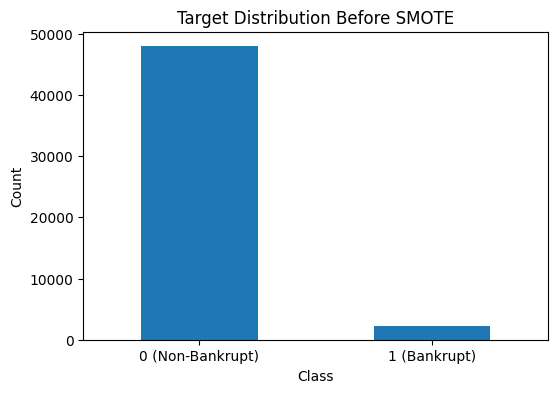


Resampled Target Distribution:
1    0.5
0    0.5
Name: proportion, dtype: float64


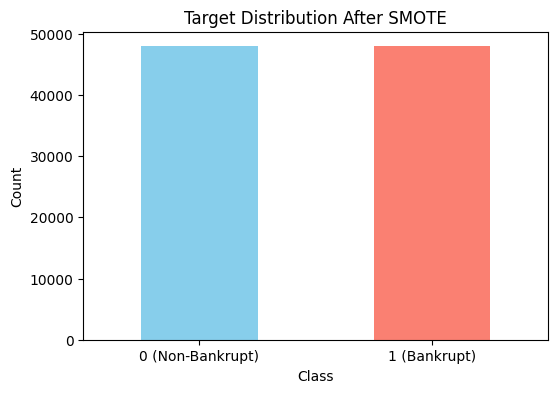

In [ ]:
# %%
# Visualize Target Distribution Before SMOTE
# Need the original y data

import matplotlib.pyplot as plt

print("Original Target Distribution:")
print(y.value_counts(normalize=True))

plt.figure(figsize=(6, 4))
y.value_counts().plot(kind='bar')
plt.title("Target Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=['0 (Non-Bankrupt)', '1 (Bankrupt)'], rotation=0)
plt.show()

# %%
# Visualize Target Distribution After SMOTE
print("\nResampled Target Distribution:")
print(y_resampled.value_counts(normalize=True))

plt.figure(figsize=(6, 4))
y_resampled.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Target Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=['0 (Non-Bankrupt)', '1 (Bankrupt)'], rotation=0)
plt.show()

In [ ]:
# Import necessary libraries
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

# Define parameters for GridSearchCV (assuming these are the desired parameters)
params = {
    'num_leaves': [31, 50],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [100, 200]
}

grid = GridSearchCV(
    lgb.LGBMClassifier(random_state=42),
    params,
    cv=5,
    scoring='f1',
    n_jobs=-1,  # use all CPU cores
)

In [ ]:
estimator = lgb.LGBMClassifier(random_state=42)



grid = GridSearchCV(estimator, params, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 38330, number of negative: 38330
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.111254 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 38898
[LightGBM] [Info] Number of data points in the train set: 76660, number of used features: 158
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best parameters: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 50}


In [ ]:
# Replace this with your best_params_ result
best_params = {
    'num_leaves': 50,
    'learning_rate': 0.01,
    'n_estimators': 200
}

# Retrain model
from lightgbm import LGBMClassifier
final_model = LGBMClassifier(**best_params, random_state=42)
final_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 38330, number of negative: 38330
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.108985 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 38898
[LightGBM] [Info] Number of data points in the train set: 76660, number of used features: 158
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(learning_rate=0.01, n_estimators=200, num_leaves=50,
               random_state=42)

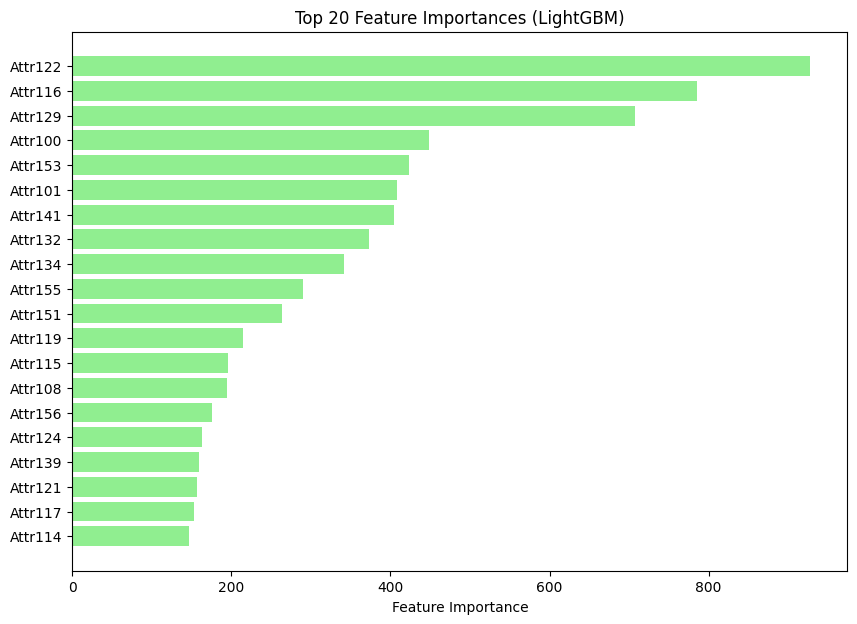

In [ ]:
# Visualize Feature Importances from the LGBM model
import numpy as np

# Get feature importances
feature_importances = final_model.feature_importances_

# Get feature names (using generic names as the original column names were dropped during concatenation)
# You might want to map these back to original names if you have them stored
feature_names = [f'Attr{i+1}' for i in range(X_scaled.shape[1])]

# Create a DataFrame for easier handling and sorting
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})

# Sort by importance
importance_df = importance_df.sort_values('importance', ascending=False)

# Select top N features for visualization (e.g., top 20)
top_n = 20
importance_df_top_n = importance_df.head(top_n)

plt.figure(figsize=(10, 7))
plt.barh(importance_df_top_n['feature'], importance_df_top_n['importance'], color='lightgreen')
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Feature Importances (LightGBM)")
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

In [ ]:
# Make predictions on the test set
y_pred = final_model.predict(X_test)
print(y_pred)
# %%
# Evaluate the model
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score

# Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[0 0 0 ... 1 0 1]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92      9583
           1       0.92      0.92      0.92      9583

    accuracy                           0.92     19166
   macro avg       0.92      0.92      0.92     19166
weighted avg       0.92      0.92      0.92     19166



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


ROC AUC: 0.9812622168271672


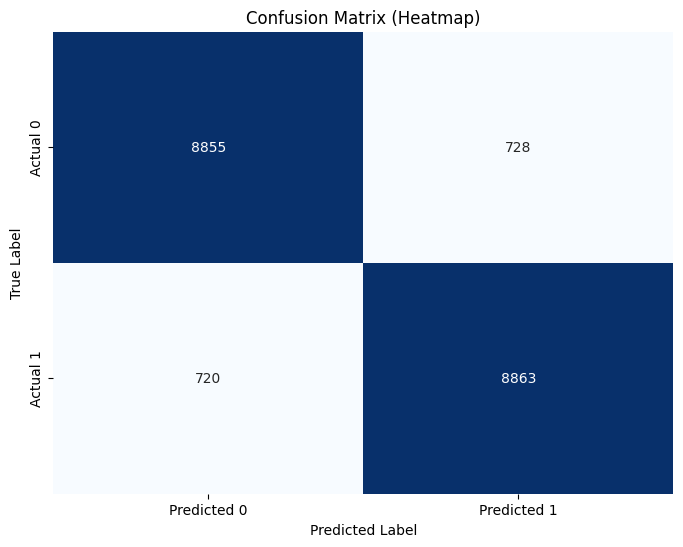

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


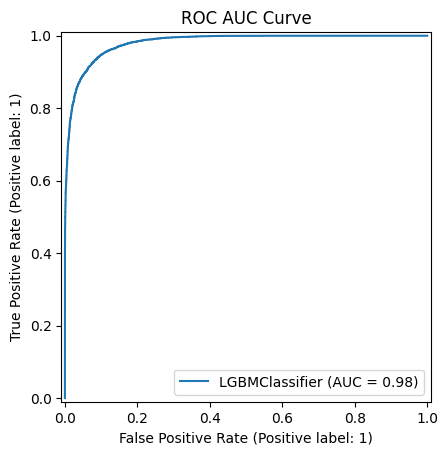

In [ ]:
# Calculate and print ROC AUC score
# We need predict_proba for ROC AUC
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

# %%
# Visualize Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay # Import ConfusionMatrixDisplay and RocCurveDisplay
import matplotlib.pyplot as plt # Import matplotlib
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title("Confusion Matrix (Heatmap)")
plt.show()

# %%
# Visualize ROC AUC Curve
RocCurveDisplay.from_estimator(final_model, X_test, y_test)
plt.title("ROC AUC Curve")
plt.show()

In [ ]:
# Install SHAP if not already
!pip install shap



100%|===================| 19136/19166 [04:08<00:00]       

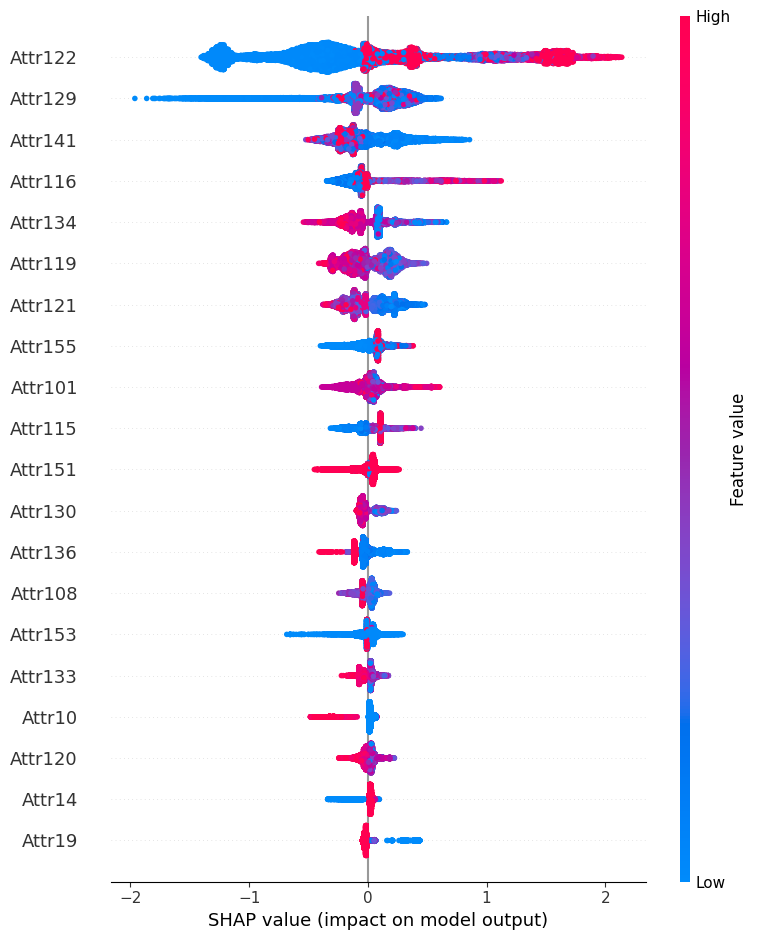

In [ ]:
import shap
import pandas as pd # Ensure pandas is imported if needed for feature_names

# Create SHAP explainer
# Pass the scaled training data X_train that the model was trained on
# Removed check_additivity as it is not a valid parameter for TreeExplainer
explainer = shap.Explainer(final_model, X_train, feature_names=feature_names)

# Compute SHAP values for the test set (scaled data)
# Set check_additivity=False to bypass the check that is causing the error
shap_values = explainer(X_test, check_additivity=False)

# Global feature importance (SHAP summary plot)
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

# Optional: Individual prediction explanation
# shap.plots.waterfall(shap_values[0])  # Uncomment to view a single prediction breakdown

In [ ]:
# ------------------------------------------
# ➕ Add Z-score Volatility Index Feature
# ------------------------------------------
import numpy as np # Ensure numpy is imported

# Reuse X_scaled to compute z-scores
z_scores = (X_scaled - X_scaled.mean(axis=0)) / (X_scaled.std(axis=0) + 1e-6)

# For each row, compute standard deviation of z-scores (i.e., volatility across features)
z_score_volatility = z_scores.std(axis=1)

# Calculate row-wise features (mean, std, coefficient of variation)
row_means = X_scaled.mean(axis=1)
row_stds = X_scaled.std(axis=1)
# Calculate coefficient of variation, add epsilon to denominator to prevent division by zero
row_cv = row_stds / (row_means + 1e-6)


# Append as a new column
X_augmented = np.hstack([
    X_scaled,
    row_means.reshape(-1, 1),
    row_stds.reshape(-1, 1),
    row_cv.reshape(-1, 1),
    z_score_volatility.reshape(-1, 1)
])

# Update feature names
feature_names = [f'Attr{i+1}' for i in range(X_scaled.shape[1])] + ['row_mean', 'row_std', 'row_cv', 'z_score_volatility']

print("Final augmented shape:", X_augmented.shape)

Final augmented shape: (50224, 163)
